# Предсказание цены сборки ПК

**Задача:** По характеристикам компонентов предсказать итоговую стоимость сборки (`Build_Price_RUB`).



**Тип задачи:** Регрессия

**Признаки:** бренды, типы компонентов, частоты, объёмы, количество ядер, чипсеты и т.д.  
**Целевая переменная:** `Build_Price_RUB`

**Сравниваемые модели:**

| Модель | Примечание |
|---|---|
| Linear Regression | Базовая линия |
| Ridge Regression | Линейная с L2-регуляризацией |
| Random Forest | Ансамбль деревьев |
| HistGradientBoosting | Градиентный бустинг (sklearn, аналог XGBoost) |
| MLP Neural Network | Многослойный перцептрон |

## 1. Импорт библиотек

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')


## 2. Загрузка и первичный осмотр

In [183]:
df = pd.read_csv('Pc_build_data_enriched.csv')

print(f'Размер датасета: {df.shape[0]:,} строк x {df.shape[1]} столбцов')
df.head(3)

Размер датасета: 20,000 строк x 40 столбцов


,BuildID,PSU_Brand,Cabinet_Brand,RAM_Brand,Cabinet_Type,GPU_Tier,CPU_Cores,CPU_Threads,PSU_Wattage,Motherboard_Chipset,...,Component_Price_Storage,Assembly_Fee,Build_Price_RUB,efficiency,Build_Notes,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Billing_Type
0,BUILD-00001,EVGA,Antec,Patriot,Full Tower,4,2,4,1000,X570,...,2959,3500,206301,0.000019,Chipset efficiency threading cache profile sta...,NaN,NaN,NaN,NaN,Cash on Delivery
1,BUILD-00002,Seasonic,Cooler Master,Kingston,Mid Tower,2,2,4,450,B660,...,4255,3500,93593,0.000021,Scalability reliability quiet latency thermal ...,NaN,NaN,NaN,NaN,Cash on Delivery
2,BUILD-00003,EVGA,Antec,Patriot,Mini-ITX,2,16,32,450,A520,...,13417,3500,158398,0.000013,Benchmark profile aerodynamics reliability vrm...,NaN,NaN,NaN,NaN,Cash on Delivery


In [184]:
df.dtypes.to_frame('dtype').T

,BuildID,PSU_Brand,Cabinet_Brand,RAM_Brand,Cabinet_Type,GPU_Tier,CPU_Cores,CPU_Threads,PSU_Wattage,Motherboard_Chipset,...,Component_Price_Storage,Assembly_Fee,Build_Price_RUB,efficiency,Build_Notes,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Billing_Type
dtype,object,object,object,object,object,int64,int64,int64,int64,object,...,int64,int64,int64,float64,object,float64,float64,float64,float64,object


In [185]:
missing = df.isnull().sum()
missing_report = missing[missing > 0]
if missing_report.empty:
    print('Пропусков нет')
else:
    print(missing_report)

Unnamed: 34    20000
Unnamed: 35    20000
Unnamed: 36    20000
Unnamed: 37    20000
dtype: int64


## 3. Разведочный анализ (EDA)

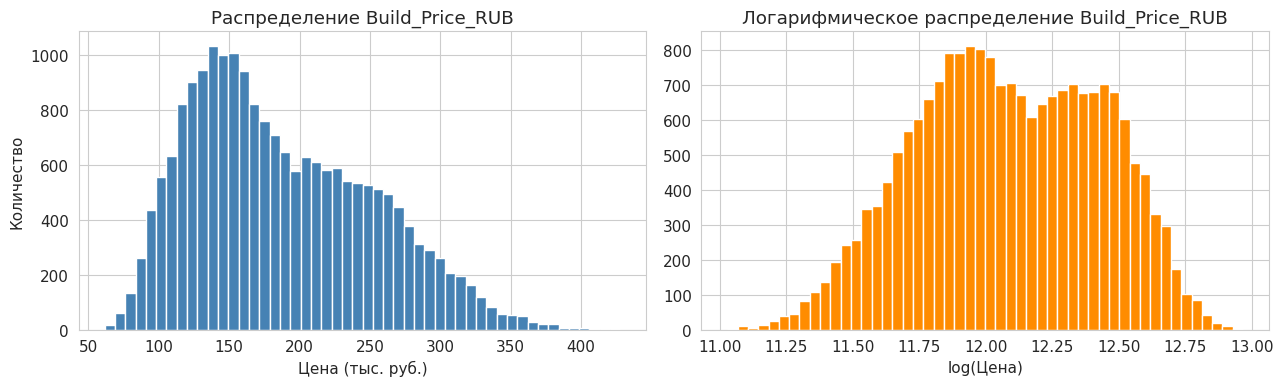

Статистика:
count     20,000 руб.
mean     187,482 руб.
std       64,252 руб.
min       61,585 руб.
25%      136,642 руб.
50%      175,407 руб.
75%      234,498 руб.
max      427,886 руб.
Name: Build_Price_RUB, dtype: object


In [181]:
# Распределение целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Build_Price_RUB'] / 1000, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение Build_Price_RUB')
axes[0].set_xlabel('Цена (тыс. руб.)')
axes[0].set_ylabel('Количество')

axes[1].hist(np.log1p(df['Build_Price_RUB']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Логарифмическое распределение Build_Price_RUB')
axes[1].set_xlabel('log(Цена)')

plt.tight_layout()
plt.show()

print('Статистика:')
print(df['Build_Price_RUB'].describe().apply(lambda x: f'{x:,.0f} руб.'))

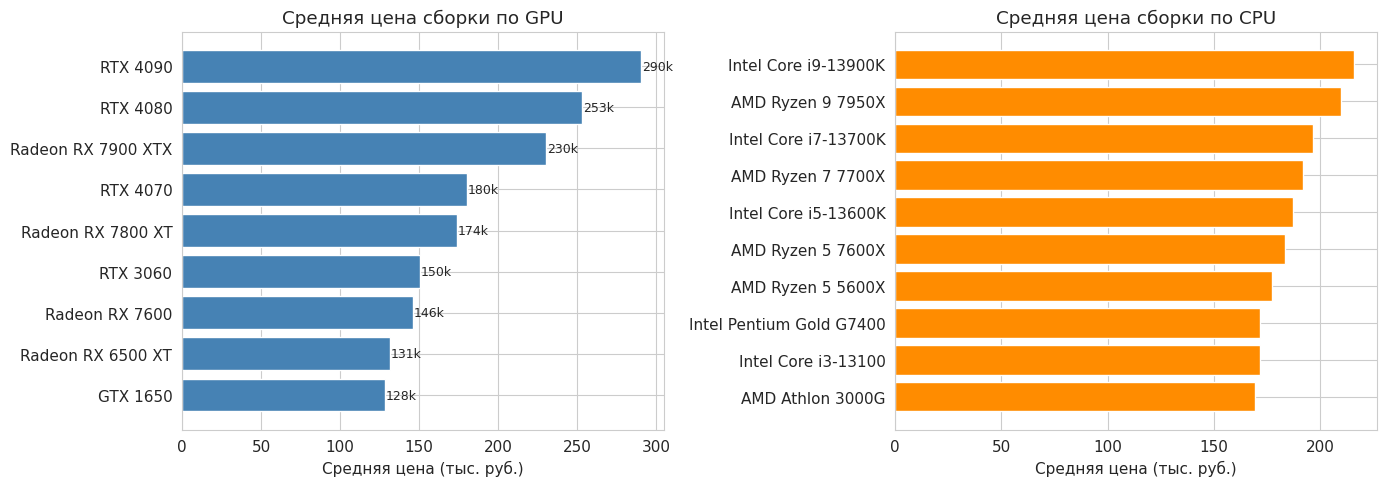

In [158]:
# Средняя цена по GPU и CPU
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gpu_price = df.groupby('GPU_Model')['Build_Price_RUB'].mean().sort_values()
bars = axes[0].barh(gpu_price.index, gpu_price.values / 1000, color='steelblue')
axes[0].set_xlabel('Средняя цена (тыс. руб.)')
axes[0].set_title('Средняя цена сборки по GPU')
for bar, val in zip(bars, gpu_price.values):
    axes[0].text(val/1000 + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val/1000:.0f}k', va='center', fontsize=9)

cpu_price = df.groupby('CPU_Model')['Build_Price_RUB'].mean().sort_values()
axes[1].barh(cpu_price.index, cpu_price.values / 1000, color='darkorange')
axes[1].set_xlabel('Средняя цена (тыс. руб.)')
axes[1].set_title('Средняя цена сборки по CPU')

plt.tight_layout()
plt.show()

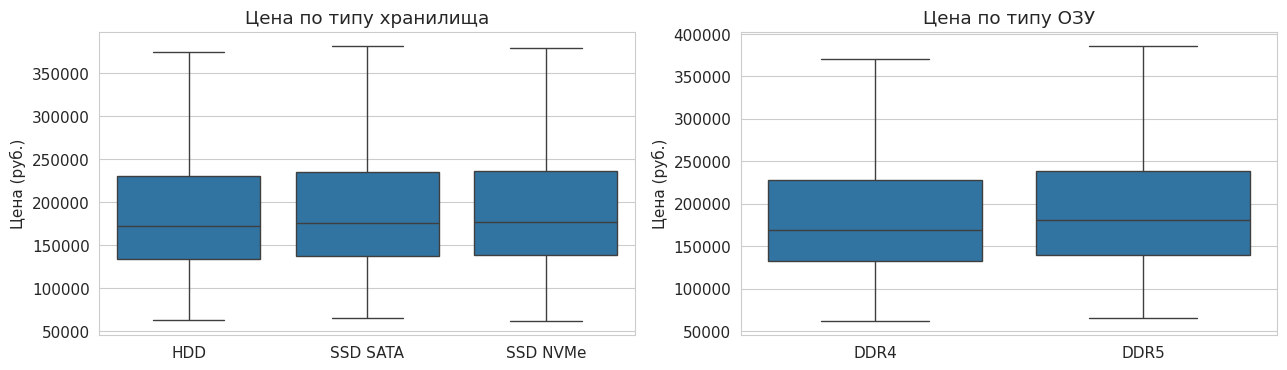

In [186]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Первый график
order_st = df.groupby('Storage_Type')['Build_Price_RUB'].median().sort_values().index
sns.boxplot(data=df, x='Storage_Type', y='Build_Price_RUB',
            order=order_st, ax=axes[0], showfliers=False)
axes[0].set_title('Цена по типу хранилища')
axes[0].set_xlabel('')
axes[0].set_ylabel('Цена (руб.)')

# Второй график
order_rt = df.groupby('RAM_Type')['Build_Price_RUB'].median().sort_values().index
sns.boxplot(data=df, x='RAM_Type', y='Build_Price_RUB',
            order=order_rt, ax=axes[1], showfliers=False)
axes[1].set_title('Цена по типу ОЗУ')
axes[1].set_xlabel('')
axes[1].set_ylabel('Цена (руб.)')

plt.suptitle('')
plt.tight_layout()
plt.show()

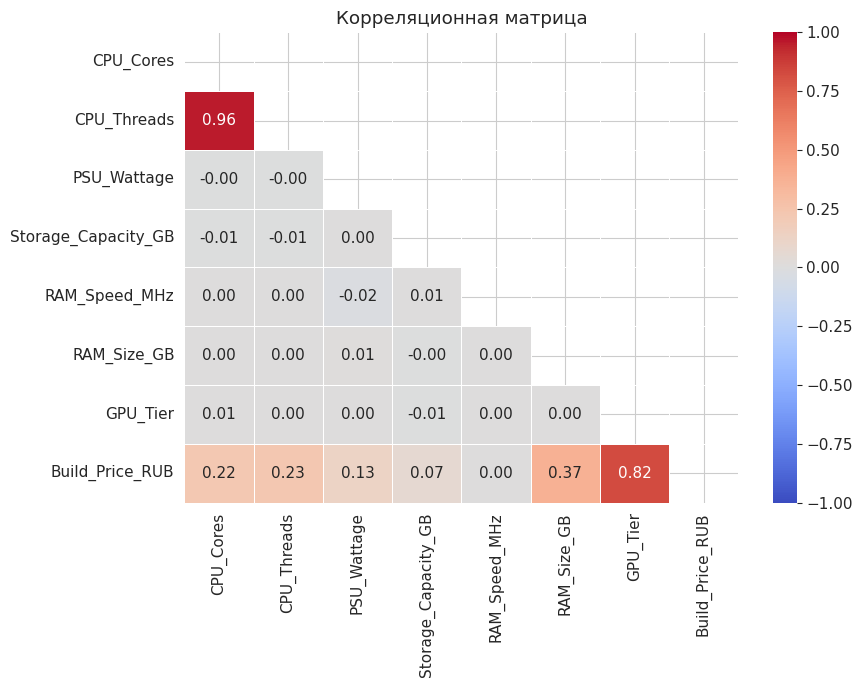

In [190]:
# Корреляционная матрица числовых признаков
num_cols = ['CPU_Cores', 'CPU_Threads', 'PSU_Wattage', 'Storage_Capacity_GB',
            'RAM_Speed_MHz', 'RAM_Size_GB', 'GPU_Tier', 'Build_Price_RUB']

corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

## 4. Подготовка признаков

In [198]:
# Признаки для обучения.
# Исключаем:
#   - Component_Price_* и Assembly_Fee: их сумма и есть Build_Price_RUB -> утечка данных
#   - efficiency: производный от Build_Price_RUB -> утечка данных
#   - Motherboard_Model: очень высокая кардинальность, нет смысловой пользы
#   - Build_Notes: текст, отдельная NLP-задача
#   - Служебные столбцы (BuildID, Billing_Type, Unnamed)

DROP_COLS = [
    'BuildID', 'Build_Notes', 'Billing_Type',
    'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37',
    'Component_Price_CPU', 'Component_Price_Motherboard', 'Component_Price_RAM',
    'Component_Price_GPU', 'Component_Price_Cooler', 'Component_Price_Cabinet',
    'Component_Price_PSU', 'Component_Price_Storage', 'Assembly_Fee',
    'Motherboard_Model',
    'efficiency',
]

TARGET = 'Build_Price_RUB'

feature_cols = [c for c in df.columns if c not in DROP_COLS + [TARGET]]
print(f'Итого признаков: {len(feature_cols)}')
print(feature_cols)

Итого признаков: 21
['PSU_Brand', 'Cabinet_Brand', 'RAM_Brand', 'Cabinet_Type', 'GPU_Tier', 'CPU_Cores', 'CPU_Threads', 'PSU_Wattage', 'Motherboard_Chipset', 'Storage_Capacity_GB', 'RAM_Speed_MHz', 'GPU_Brand', 'Storage_Type', 'RAM_Type', 'Cooler_Brand', 'Cooler_Type', 'CPU_Brand', 'Motherboard_Brand', 'RAM_Size_GB', 'GPU_Model', 'CPU_Model']


In [199]:
X = df[feature_cols].copy()
y = df[TARGET].copy()

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'Числовые ({len(num_features)}): {num_features}')
print(f'Категориальные ({len(cat_features)}): {cat_features}')

Числовые (7): ['GPU_Tier', 'CPU_Cores', 'CPU_Threads', 'PSU_Wattage', 'Storage_Capacity_GB', 'RAM_Speed_MHz', 'RAM_Size_GB']
Категориальные (14): ['PSU_Brand', 'Cabinet_Brand', 'RAM_Brand', 'Cabinet_Type', 'Motherboard_Chipset', 'GPU_Brand', 'Storage_Type', 'RAM_Type', 'Cooler_Brand', 'Cooler_Type', 'CPU_Brand', 'Motherboard_Brand', 'GPU_Model', 'CPU_Model']


In [200]:
# Label Encoding категориальных признаков
le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

print('Label Encoding применён')
X.head(3)

Label Encoding применён


,PSU_Brand,Cabinet_Brand,RAM_Brand,Cabinet_Type,GPU_Tier,CPU_Cores,CPU_Threads,PSU_Wattage,Motherboard_Chipset,Storage_Capacity_GB,...,GPU_Brand,Storage_Type,RAM_Type,Cooler_Brand,Cooler_Type,CPU_Brand,Motherboard_Brand,RAM_Size_GB,GPU_Model,CPU_Model
0,4,0,5,0,4,2,4,1000,6,256,...,1,0,1,5,0,0,2,16,8,9
1,5,1,4,2,2,2,4,450,3,256,...,0,1,0,0,3,0,2,32,1,0
2,4,0,5,3,2,16,32,450,0,1000,...,0,1,1,2,1,0,2,64,6,4


In [201]:
# Разбивка 80% / 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Обучающая выборка: {X_train.shape[0]:,}')
print(f'Тестовая выборка:  {X_test.shape[0]:,}')

Обучающая выборка: 16,000
Тестовая выборка:  4,000


In [203]:
# Масштабирование для линейных моделей и MLP
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


## 5. Обучение моделей

In [205]:
def evaluate(name, model, X_tr, X_te):
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    print(f'{name:<35}  MAE={mae:>10,.0f}  RMSE={rmse:>11,.0f}  R2={r2:.4f}  MAPE={mape:.2f}%')
    return {'model': model, 'name': name,
            'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape, 'y_pred': y_pred}

results = {}

In [206]:
results['lr'] = evaluate('Linear Regression',
                         LinearRegression(), X_train_sc, X_test_sc)

Linear Regression                    MAE=    15,122  RMSE=     18,575  R2=0.9171  MAPE=8.84%


In [207]:
results['ridge'] = evaluate('Ridge Regression (alpha=10)',
                             Ridge(alpha=10.0), X_train_sc, X_test_sc)

Ridge Regression (alpha=10)          MAE=    15,122  RMSE=     18,576  R2=0.9171  MAPE=8.84%


In [208]:
results['rf'] = evaluate('Random Forest',
                          RandomForestRegressor(
                              n_estimators=200, max_depth=20,
                              random_state=42, n_jobs=-1),
                          X_train, X_test)

Random Forest                        MAE=     8,952  RMSE=     11,553  R2=0.9679  MAPE=4.94%


In [209]:
results['hgb'] = evaluate('HistGradientBoosting',
                           HistGradientBoostingRegressor(
                               max_iter=500, learning_rate=0.05,
                               max_depth=6, random_state=42),
                           X_train, X_test)

HistGradientBoosting                 MAE=     6,145  RMSE=      8,139  R2=0.9841  MAPE=3.19%


In [210]:
results['mlp'] = evaluate('MLP Neural Network',
                           MLPRegressor(
                               hidden_layer_sizes=(256, 128, 64),
                               activation='relu', max_iter=300,
                               early_stopping=True, random_state=42),
                           X_train_sc, X_test_sc)

MLP Neural Network                   MAE=     9,789  RMSE=     12,496  R2=0.9625  MAPE=5.46%


## 6. Сравнение моделей

In [211]:
metrics_df = pd.DataFrame([
    {'Модель': v['name'], 'MAE (руб.)': round(v['mae']),
     'RMSE (руб.)': round(v['rmse']), 'R2': round(v['r2'], 4),
     'MAPE (%)': round(v['mape'], 2)}
    for v in results.values()
]).sort_values('R2', ascending=False).reset_index(drop=True)

metrics_df

,Модель,MAE (руб.),RMSE (руб.),R2,MAPE (%)
0,HistGradientBoosting,6145,8139,0.9841,3.19
1,Random Forest,8952,11553,0.9679,4.94
2,MLP Neural Network,9789,12496,0.9625,5.46
3,Linear Regression,15122,18575,0.9171,8.84
4,Ridge Regression (alpha=10),15122,18576,0.9171,8.84


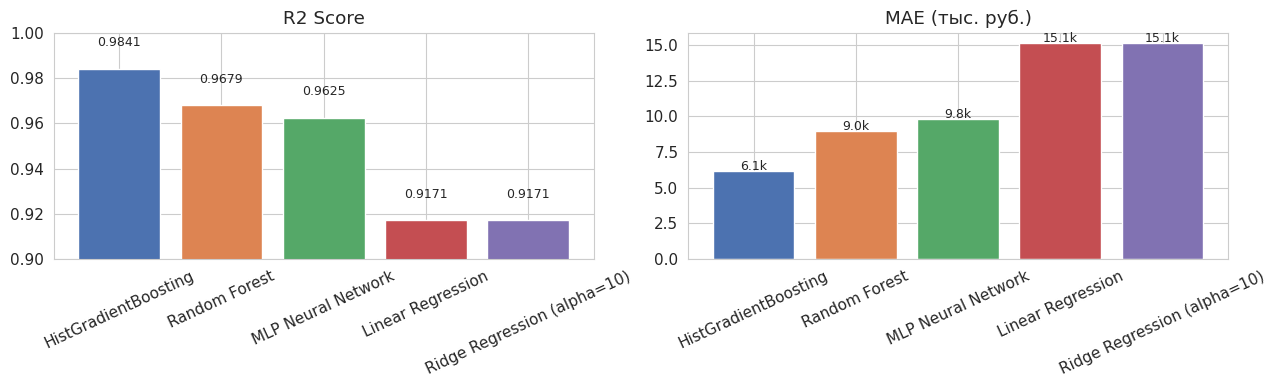

In [215]:
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
names = metrics_df['Модель']

bars0 = axes[0].bar(names, metrics_df['R2'], color=colors)
axes[0].set_title('R2 Score')
axes[0].set_ylim(0.9, 1)
axes[0].tick_params(axis='x', rotation=25)
for bar, val in zip(bars0, metrics_df['R2']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.4f}', ha='center', fontsize=9)

bars1 = axes[1].bar(names, metrics_df['MAE (руб.)'] / 1000, color=colors)
axes[1].set_title('MAE (тыс. руб.)')
axes[1].tick_params(axis='x', rotation=25)
for bar, val in zip(bars1, metrics_df['MAE (руб.)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val/1000 + 0.1,
                 f'{val/1000:.1f}k', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Детальный анализ лучшей модели

In [216]:
best_key = max(results, key=lambda k: results[k]['r2'])
worst_key = min(results, key=lambda k: results[k]['r2'])
best = results[best_key]
worst = results[worst_key]
print(f'Лучшая модель: {best["name"]}')
print(f'  R2   = {best["r2"]:.4f}')
print(f'  MAE  = {best["mae"]:,.0f} руб.')
print(f'  RMSE = {best["rmse"]:,.0f} руб.')
print(f'  MAPE = {best["mape"]:.2f}%')

Лучшая модель: HistGradientBoosting
  R2   = 0.9841
  MAE  = 6,145 руб.
  RMSE = 8,139 руб.
  MAPE = 3.19%


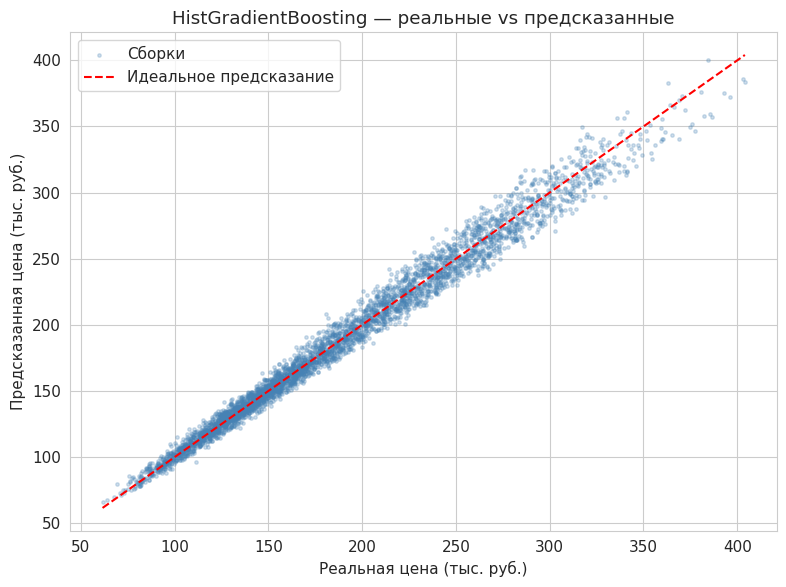

In [217]:
# Реальные vs предсказанные
y_pred_best = best['y_pred']
y_pred_worst = worst['y_pred']
plt.figure(figsize=(8, 6))
plt.scatter(y_test / 1000, y_pred_best / 1000, alpha=0.25, s=6,
            color='steelblue', label='Сборки')
lims = [min(y_test.min(), y_pred_best.min()) / 1000,
        max(y_test.max(), y_pred_best.max()) / 1000]
plt.plot(lims, lims, 'r--', lw=1.5, label='Идеальное предсказание')
plt.xlabel('Реальная цена (тыс. руб.)')
plt.ylabel('Предсказанная цена (тыс. руб.)')
plt.title(f'{best["name"]} — реальные vs предсказанные')
plt.legend()
plt.tight_layout()
plt.show()

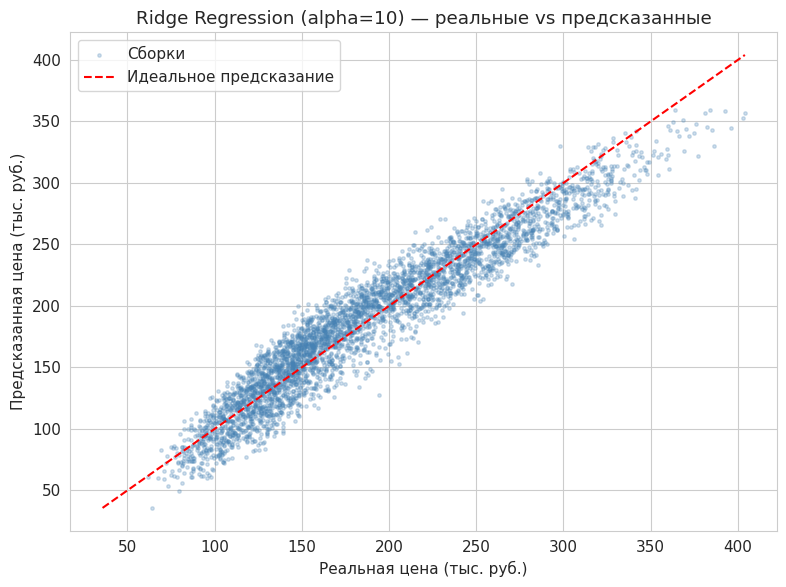

In [218]:
y_pred_worst = worst['y_pred']
plt.figure(figsize=(8, 6))
plt.scatter(y_test / 1000, y_pred_worst / 1000, alpha=0.25, s=6,
            color='steelblue', label='Сборки')
lims = [min(y_test.min(), y_pred_worst.min()) / 1000,
        max(y_test.max(), y_pred_worst.max()) / 1000]
plt.plot(lims, lims, 'r--', lw=1.5, label='Идеальное предсказание')
plt.xlabel('Реальная цена (тыс. руб.)')
plt.ylabel('Предсказанная цена (тыс. руб.)')
plt.title(f'{worst["name"]} — реальные vs предсказанные')
plt.legend()
plt.tight_layout()
plt.show()

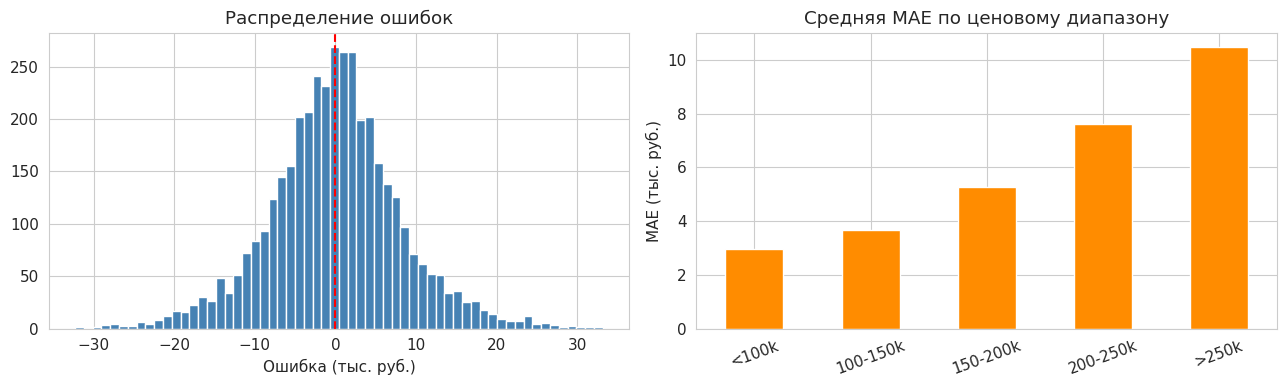

Смещение: -50 руб.  |  Std: 8,139 руб.


In [219]:
# Распределение ошибок и ошибка по ценовому диапазону
errors = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(errors / 1000, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Ошибка (тыс. руб.)')
axes[0].set_title('Распределение ошибок')

df_err = pd.DataFrame({'y_true': y_test.values / 1000,
                       'abs_error': np.abs(errors) / 1000})
df_err['bin'] = pd.cut(df_err['y_true'],
                        bins=[0, 100, 150, 200, 250, 9999],
                        labels=['<100k', '100-150k', '150-200k', '200-250k', '>250k'])
df_err.groupby('bin', observed=True)['abs_error'].mean().plot(
    kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Средняя MAE по ценовому диапазону')
axes[1].set_xlabel('')
axes[1].set_ylabel('MAE (тыс. руб.)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print(f'Смещение: {errors.mean():,.0f} руб.  |  Std: {errors.std():,.0f} руб.')

Вычисление важности признаков для Random Forest...
Вычисление важности признаков для HistGradientBoosting...


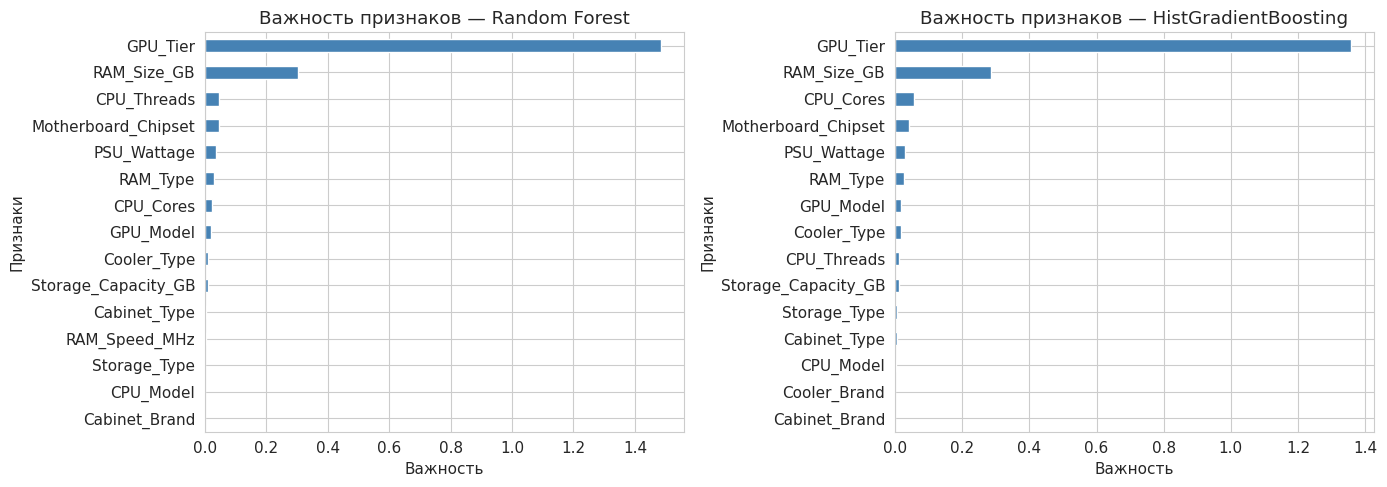

In [220]:
from sklearn.inspection import permutation_importance

# Важность признаков для tree-based моделей
tree_keys = [k for k in ('rf', 'hgb') if k in results]
fig, axes = plt.subplots(1, len(tree_keys), figsize=(14, 5))
if len(tree_keys) == 1:
    axes = [axes]

for ax, key in zip(axes, tree_keys):
    res = results[key]
    model = res['model']

    # Используем permutation importance для обеих моделей (для единообразия)
    print(f"Вычисление важности признаков для {res['name']}...")
    perm_importance = permutation_importance(
        model, X_train, y_train,
        n_repeats=10,           # количество перестановок
        random_state=42,        # для воспроизводимости
        n_jobs=-1               # использовать все ядра процессора
    )

    imp = pd.Series(
        perm_importance.importances_mean,
        index=X_train.columns
    ).sort_values(ascending=True).tail(15)

    imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Важность признаков — {res["name"]}')
    ax.set_xlabel('Важность')
    ax.set_ylabel('Признаки')

plt.tight_layout()
plt.show()

## 8. Кросс-валидация лучшей модели

Кросс-валидация (5-fold) — HistGradientBoosting
  R2:  0.9838 +/- 0.0002
  MAE: 6,204 +/- 61 руб.


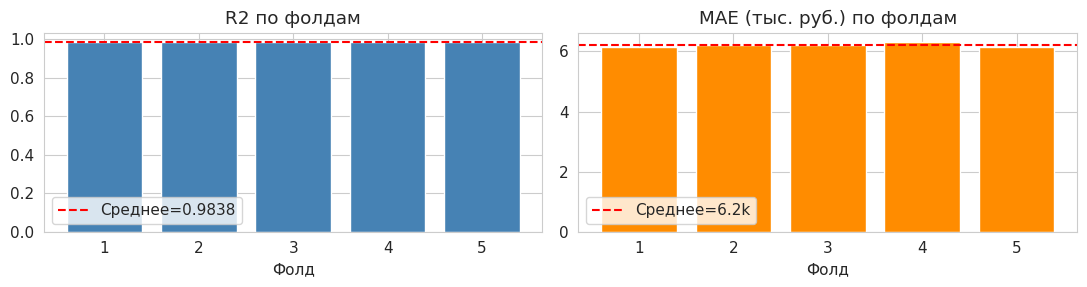

In [221]:
cv_model = results[best_key]['model']
X_cv = X_train_sc if best_key in ('lr', 'ridge', 'mlp') else X_train

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2  = cross_val_score(cv_model, X_cv, y_train, cv=kf, scoring='r2', n_jobs=-1)
cv_mae = -cross_val_score(cv_model, X_cv, y_train, cv=kf,
                           scoring='neg_mean_absolute_error', n_jobs=-1)

print(f'Кросс-валидация (5-fold) — {best["name"]}')
print(f'  R2:  {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')
print(f'  MAE: {cv_mae.mean():,.0f} +/- {cv_mae.std():,.0f} руб.')

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].bar(range(1, 6), cv_r2, color='steelblue')
axes[0].axhline(cv_r2.mean(), color='red', linestyle='--',
                label=f'Среднее={cv_r2.mean():.4f}')
axes[0].set_title('R2 по фолдам'); axes[0].set_xlabel('Фолд')
axes[0].legend()

axes[1].bar(range(1, 6), cv_mae / 1000, color='darkorange')
axes[1].axhline(cv_mae.mean() / 1000, color='red', linestyle='--',
                label=f'Среднее={cv_mae.mean()/1000:.1f}k')
axes[1].set_title('MAE (тыс. руб.) по фолдам'); axes[1].set_xlabel('Фолд')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Итоги

### Сводка по моделям

| Модель | Тип | Нелинейность | Требует масштабирования |
|---|---|---|---|
| Linear Regression | Линейная | Нет | Да |
| Ridge | Линейная + L2 | Нет | Да |
| Random Forest | Ансамбль деревьев | Да | Нет |
| HistGradientBoosting | Бустинг | Да | Нет |
| MLP | Нейросеть | Да | Да |

### Выводы

1. **GPU_Model и RAM_Size — ключевые факторы цены** по важности признаков у обоих tree-based моделей
2. **Tree-based модели превосходят линейные** — зависимость нелинейная (топ-GPU резко увеличивает цену)
3. **Линейные модели дают хороший R2 (~0.92)** — в данных есть сильные линейные корреляции
